## Omnimind Agent System

In [2]:
import os
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from typing import TypedDict
import ast
import numpy as np

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### LLM

In [3]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001D07AAF4550>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D07B00A650>, root_client=<openai.OpenAI object at 0x000001D07AAF4090>, root_async_client=<openai.AsyncOpenAI object at 0x000001D07B00A150>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Agent State

In [4]:
class AgentState(TypedDict):
    query: str
    route: str
    
    math_result: str
    code_result: str
    data_result: str
    summary_result: str
    general_result: str
    
    final_result: str
    
    retries: int
    valid: bool
    
AgentState

__main__.AgentState

### Tools

#### Percentage

In [5]:
@tool
def percentage_calc_tool(value: float, percentage: float) -> str:
    '''Calculate Percentage'''
    
    print('\n[TOOL: Percentage Calculator]')
    try:
        return str((value*percentage)/100)
    except Exception as e:
        return f"Claculation Error {e}"

#### Mean

In [6]:
@tool
def calculate_mean_tool(numbers: str) -> str:
    '''Calculates mean of numbers separated by comma'''

    print('\n[TOOL: Calculate Mean]')
    try:
        nums= np.array(numbers.split(',')).astype(float)
        return nums.mean()
    except Exception as e:
        return f'Mean Error {e}'

#### Code Validator

In [7]:
@tool
def code_validator_tool(code: str) -> str:
    '''Validates Python code using AST parsing'''

    print('\n[TOOL: Code Validator]')
    try:
        ast.parse(code)
        return "Code issyntactically valid"
    except SyntaxError as e:
        return f"Syntax Error: {e}"
    except IndentationError as e:
        return f'Indentation Error: {e}'
    except Exception as e:
        print(f'Code Validation Error: {e}')

#### Keyword Extractor

In [8]:
@tool
def keyword_extractor_tool(text: str) -> str:
    '''Extracts first 5 words from the given text'''
    
    print('\n[TOOL: Keyword Extractor]')
    try:
        return ','.join(text.split(',')[:5])
    except Exception as e:
        return f'Keyword Extraction Error: {e}'

### Agents

#### Math Agent

In [10]:
math_agent = create_agent(
    model=llm,
    tools=[percentage_calc_tool],

    system_prompt='''You are a math expert. You always use the given tool when needed.'''
)

#### Coding Agent

In [11]:
coding_agent = create_agent(
    model=llm,
    tools=[code_validator_tool],
    
    system_prompt='''You are a coding expert.
    Generate correct Python code and always validate it with the given tool'''
)

#### Data Analysis Agent

In [13]:
data_agent = create_agent(
    model=llm,
    tools=[calculate_mean_tool, keyword_extractor_tool],
    
    system_prompt='''You are a data analyst.
    Always use the given tools to analyse the data and to extract the keywords as needed'''
)

#### Summary Agent

In [14]:
summary_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful assistant.
    Summarise the given text simply and precisly without losing the main context and the information given in the text. '''
)

#### General Agent

In [15]:
general_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful assistant. You answer the general queries very briefly with in 100 words.'''
)

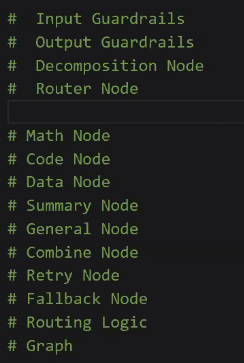

### Nodes

In [ ]:
def input_guardrails(query):
    print('\n[INPUT GUARDRAILS] ', query)
        
    # Empty check
    if not query.strip():
        # return {'valid': False}
        return False
    
    # Keyword check
    banned_keywords = ['hack', 'attack', 'illegal', 'ignore instructions', 'no restrictions', 'system prompt']
    if any(word in query.lower() for word in banned_keywords):
        # return {'valid': False}
        return False
        
    # return {'valid': True}
    return True

In [56]:
def output_guardrails(result):
    print('\n[OUTPUT GUARDRAILS NODE]')

    # Empty check
    if not result.strip():
        return False
    
    return True

In [35]:
def decomposition_node(state):
    print('\n[DECOMPOSITION NODE]')
    query = state['query']
    
    try:
        prompt = f'''Break the query into tasks if it is a complex query as per the tools below.
        
We have the following tools:
Math -> Soles maths expressions
Code -> Gnenerate Python code
Summarise -> Summarise the text or the query
General -> Answer general queries
Decompose any query so that a complete query is realted to a partcilar tool.

QUERY:
{query}
'''

        result = llm.invoke(prompt).content.strip()
        # result = ast.literal_eval(result) # convert to list
        print('[DECOMPOSED TASKS]')
        print(result)
        return {'query': result}
    except Exception as e:
        print(f'Decompsition Error: {e}')
        return {'query': query}

In [38]:
def router_node(state):
    print('\n[ROUTER NODE]')
    
    try:    
        prompt = f'''Decide which agent(s) to use based upon the given query. Return only the agent name.
        
    AGENTS:
        - math
        - coding
        - data analysis
        - summary
        - general

    QUERY:
    {state['query']}'''

        agent_name = llm.invoke(prompt).content.strip()
        print('\Route: ', agent_name)
        
        return {'route': agent_name}
    except Exception as e:
        print(f'Route Error: {e}')
        return {'route': 'general'}

In [47]:
def math_node(state):
    print('\n[MATH NODE]')
    try:
        result = math_agent.invoke(
            {
                "messages": [{'role' : 'user' , 'content' : state['query']}]
            }
        )
        
        answer = result['messages'][-1].content
        return {'math_result': answer}
    except Exception as e:
        print(f'Math Error: {e}')
        return {'math_result': f'Error: {e}'}

In [46]:
def coding_node(state):
    print('\n[CODING NODE]')
    try:
        result = coding_agent.invoke(
            {
                "messages": [{'role' : 'user' , 'content' : state['query']}]
            }
        )
        
        answer = result['messages'][-1].content
        return {'code_result': answer}
    except Exception as e:
        print(f'Code Error: {e}')
        return {'code_result': f'Error: {e}'}

In [45]:
def data_analysis_node(state):
    print('\n[DATA ANALYSIS NODE]')
    try:
        result = data_agent.invoke(
            {
                "messages": [{'role' : 'user' , 'content' : state['query']}]
            }
        )
        
        answer = result['messages'][-1].content
        return {'data_result': answer}
    except Exception as e:
        print(f'Data Error: {e}')
        return {'data_result': f'Error: {e}'}

In [44]:
def summary_node(state):
    print('\n[SUMMARY NODE]')
    try:
        result = summary_agent.invoke(
            {
                "messages": [{'role' : 'user' , 'content' : state['query']}]
            }
        )
        
        answer = result['messages'][-1].content
        return {'summary_result': answer}
    except Exception as e:
        print(f'Summary Error: {e}')
        return {'summary_result': f'Error: {e}'}

In [48]:
def general_node(state):
    print('\n[GENERAL NODE]')

    try:
        result = general_agent.invoke(
            {
                "messages": [{'role' : 'user' , 'content' : state['query']}]
            }
        )
        
        answer = result['messages'][-1].content
        return {'general_result': answer}
    except Exception as e:
        print(f'General Error: {e}')
        return {'general_result': f'Error: {e}'}

In [52]:
def combine_node(state):
    print('\n[COMBINE NODE]')

    try:
        result = (
            state['math_result']
            or state['code_result']
            or state['data_result']
            or state['summary_result']
            or state['general_result']
        )
        print('Final Result: ')
        print(result)
        
        return {'final_result': result}
    except Exception as e:
        print(f'Combine Error: {e}')
        return {'final_result': f'Error: {e}'}

In [57]:
def validate_node(state):
    print('\n[VALIDATE NODE]')

    res = state.get('final_result', '')
    res = res.strip()

    if res and len(res)>0 and 'error' not in res.lower():
        return {'valid' : True}
    return {'valid':False}

In [53]:
MAX_RETRIES=2
def retry_node(state):
    print('\n[RETRY NODE]')

    retries = state['retries']

    if retries >= MAX_RETRIES:
        return {'route' : 'fallback'}

    return {
        'retries':retries + 1,
        'route' : state['route']
    }

In [54]:
def fallback_node(state):
    print('\n[FALLBACK NODE]')
    try:
        result = llm.invoke(state['query']).content
        return {'final_result':result}
    except Exception as e:
        return {'final_result': 'System Failed Completely'}

### Flow

In [65]:
graph = StateGraph(AgentState)

# graph.add_node('input_guardrails_n', input_guardrails_node)
# graph.add_node('output_guardrails_n', output_guardrails_node)
graph.add_node('decomposition_n', decomposition_node)
graph.add_node('router_n', router_node)

graph.add_node('math_n', math_node)
graph.add_node('coding_n', coding_node)
graph.add_node('data_analysis_n', data_analysis_node)
graph.add_node('summary_n', summary_node)
graph.add_node('general_n', general_node)
graph.add_node('combine_n', combine_node)
graph.add_node('validate_n', validate_node)
graph.add_node('fallback_n', fallback_node)
graph.add_node('retry_n', retry_node)

In [66]:
graph.set_entry_point('decomposition_n')

graph.add_edge('decomposition_n', 'router_n')
graph.add_conditional_edges(
    'router_n',
    lambda s:s['route'],
    {
        'math': 'math_n',
        'code' : 'coding_n' ,
        'data': 'data_analysis_n',
        'summary' : 'summary_n',
        'general': 'general_n'
    }
)

graph.add_edge('math_n', 'combine_n')
graph.add_edge('coding_n', 'combine_n')
graph.add_edge('data_analysis_n', 'combine_n')
graph.add_edge('summary_n', 'combine_n')
graph.add_edge('general_n', 'combine_n')

graph.add_edge('combine_n', 'validate_n')

graph.add_conditional_edges(
    'validate_n',
    lambda s: 'valid' if s['valid'] else 'retry',
    {
        'valid': END,
        'retry': 'retry_n'
    }
)

graph.add_conditional_edges(
    'retry_n',
    lambda s:s['route'],
    {
        'math': 'math_n',
        'code' : 'coding_n' ,
        'data': 'data_analysis_n',
        'summary' : 'summary_n',
        'general': 'general_n',
        'fallback': 'fallback_n',
    }
)

graph.add_edge('fallback_n', END)

app = graph.compile()

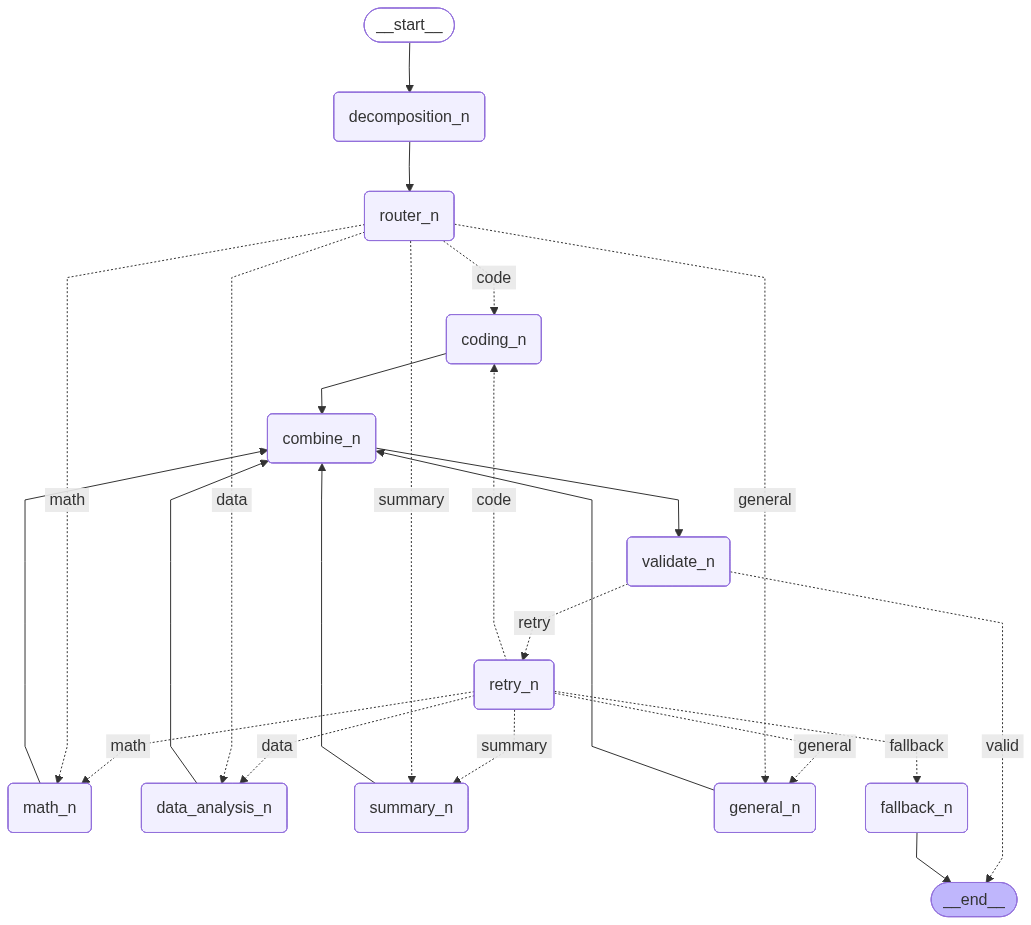

In [67]:
app